In [1]:
!pip install albumentations opencv-python lxml scikit-learn  -q

In [2]:
!pip install -q onnx onnxruntime-gpu onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 14.8 MB/s eta 0:00:00


In [3]:
!pip install optuna Pillow tqdm opencv-python numpy grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 75.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=6d1eac6083d6b4a20a02267f2b30ec01491cb2ab3907ed76d9df9239ad8e530d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


# Imports

In [4]:
# =========================
# Standard Libraries
# =========================
import os
import sys
import csv
import copy
import shutil
import random
import logging
from datetime import datetime
from pathlib import Path
from collections import defaultdict, Counter
from typing import List, Tuple

# =========================
# XML Processing
# =========================
import xml.etree.ElementTree as ET
from lxml import etree

# =========================
# Data & Numerical
# =========================
import numpy as np
import pandas as pd

# =========================
# Computer Vision
# =========================
import cv2
import albumentations as A

# =========================
# Deep Learning
# =========================
import torch
from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# =========================
# ML Utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate

# augmenter_fixed_complete.py
import os
import cv2
import copy
import numpy as np
import itertools
import shutil
from datetime import datetime
import xml.etree.ElementTree as ET
from collections import defaultdict
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# time
import time
MAX_TRAINING_TIME = int((9) * 60 * 60)  # 9 hours in seconds
print("="*10)
print(MAX_TRAINING_TIME)
print("="*10)

32400


In [5]:
import sys
import os

# Point directly to the folder where train_and_gradcam.py lives
src_dir = '/kaggle/input/models/carunmanikandan/nas-model-p-vbroken-scartch/pytorch/1.0/1/NAS_base_model'

if src_dir not in sys.path:
    sys.path.append(src_dir)

from train_and_gradcam import NASModel

# Logging

In [6]:

def setup_logger(log_dir="logs", log_name="train"):
    os.makedirs(log_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = os.path.join(log_dir, f"{log_name}_{timestamp}.log")

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler(sys.stdout)
        ]
    )

    return log_file

log_file = setup_logger()

import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Reading Dataset

In [7]:
import os
import xml.etree.ElementTree as ET

def build_class_map(xml_dir):
    class_names = set()

    for f in os.listdir(xml_dir):
        if f.endswith(".xml"):
            tree = ET.parse(os.path.join(xml_dir, f))
            root = tree.getroot()
            for obj in root.findall("object"):
                class_names.add(obj.find("name").text.strip())

    class_names = sorted(list(class_names))
    class_map = {"__background__": 0}

    for i, name in enumerate(class_names, start=1):
        class_map[name] = i

    return class_map

def parse_voc(xml_path, class_map):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes, labels = [], []

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name not in class_map:
            continue

        b = obj.find("bndbox")
        boxes.append([
            float(b.find("xmin").text),
            float(b.find("ymin").text),
            float(b.find("xmax").text),
            float(b.find("ymax").text),
        ])
        labels.append(class_map[name])

    if len(boxes) == 0:
        return None

    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor(labels, dtype=torch.int64)
    }

def get_image_classes(xml_path, class_map):
    """Get all classes present in an image"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    classes = set()
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name in class_map:
            classes.add(name)
    
    return list(classes)

def get_object_statistics(xml_dir, class_map):
    """Get detailed object statistics from XML files"""
    total_objects = 0
    images_with_objects = 0
    images_without_objects = 0
    class_object_counts = defaultdict(int)
    images_per_class = defaultdict(int)
    objects_per_image = []
    
    xml_files = [f for f in os.listdir(xml_dir) if f.endswith(".xml")]
    
    for xml_file in xml_files:
        xml_path = os.path.join(xml_dir, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        objects_in_image = 0
        classes_in_image = set()
        
        for obj in root.findall("object"):
            name = obj.find("name").text.strip()
            if name in class_map:
                total_objects += 1
                objects_in_image += 1
                class_object_counts[name] += 1
                classes_in_image.add(name)
        
        objects_per_image.append(objects_in_image)
        
        if objects_in_image > 0:
            images_with_objects += 1
            for cls in classes_in_image:
                images_per_class[cls] += 1
        else:
            images_without_objects += 1
    
    # Calculate statistics
    avg_objects_per_image = total_objects / len(xml_files) if xml_files else 0
    max_objects_per_image = max(objects_per_image) if objects_per_image else 0
    min_objects_per_image = min(objects_per_image) if objects_per_image else 0
    
    return {
        'total_objects': total_objects,
        'total_images': len(xml_files),
        'images_with_objects': images_with_objects,
        'images_without_objects': images_without_objects,
        'avg_objects_per_image': avg_objects_per_image,
        'max_objects_per_image': max_objects_per_image,
        'min_objects_per_image': min_objects_per_image,
        'class_object_counts': dict(class_object_counts),
        'images_per_class': dict(images_per_class),
        'objects_per_image_list': objects_per_image
    }

# Train Test Val Split

In [8]:
def create_stratified_splits(xml_dir, class_map, train_ratio=0.7, val_ratio=0.15, random_seed=42):
    """Create stratified splits using a simple approach"""
    # Get all XML files
    all_xml_files = sorted([f for f in os.listdir(xml_dir) if f.endswith(".xml")])
    
    # Create a simple stratification based on the presence of each class
    strat_labels = []
    
    for xml_file in all_xml_files:
        xml_path = os.path.join(xml_dir, xml_file)
        classes = get_image_classes(xml_path, class_map)
        
        if not classes:
            # Empty image
            strat_labels.append("empty")
        else:
            # Use the first class as stratification label
            strat_labels.append(classes[0])
    
    # Count occurrences of each stratification label
    from collections import Counter
    label_counts = Counter(strat_labels)
    
    # Separate files by their stratification label
    label_to_files = defaultdict(list)
    for xml_file, label in zip(all_xml_files, strat_labels):
        label_to_files[label].append(xml_file)
    
    # Initialize splits
    train_files = []
    val_files = []
    test_files = []
    
    # For each label, split its files proportionally
    for label, files in label_to_files.items():
        n_files = len(files)
        
        # Calculate number of files for each split
        n_train = max(1, int(n_files * train_ratio))
        n_val = max(1, int(n_files * val_ratio))
        n_test = n_files - n_train - n_val
        
        # Adjust if n_test is negative
        if n_test < 0:
            n_train = max(1, n_train + n_test)
            n_test = 0
        
        # Shuffle files
        random.Random(random_seed).shuffle(files)
        
        # Split
        train_files.extend(files[:n_train])
        val_files.extend(files[n_train:n_train + n_val])
        test_files.extend(files[n_train + n_val:])
    
    # Final shuffle
    random.Random(random_seed).shuffle(train_files)
    random.Random(random_seed + 1).shuffle(val_files)
    random.Random(random_seed + 2).shuffle(test_files)
    
    return train_files, val_files, test_files

def get_split_statistics(xml_dir, class_map, train_files, val_files, test_files):
    """Get detailed statistics for each split"""
    
    def get_split_stats(files):
        total_objects = 0
        class_counts = defaultdict(int)
        images_with_objects = 0
        
        for xml_file in files:
            xml_path = os.path.join(xml_dir, xml_file)
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            objects_in_image = 0
            for obj in root.findall("object"):
                name = obj.find("name").text.strip()
                if name in class_map:
                    total_objects += 1
                    objects_in_image += 1
                    class_counts[name] += 1
            
            if objects_in_image > 0:
                images_with_objects += 1
        
        return {
            'total_images': len(files),
            'total_objects': total_objects,
            'images_with_objects': images_with_objects,
            'images_without_objects': len(files) - images_with_objects,
            'avg_objects_per_image': total_objects / len(files) if files else 0,
            'class_counts': dict(class_counts)
        }
    
    train_stats = get_split_stats(train_files)
    val_stats = get_split_stats(val_files)
    test_stats = get_split_stats(test_files)
    
    return train_stats, val_stats, test_stats

# Dataset Path, intial analysis & split ratio

In [9]:
# ================== MAIN TRAINING LOOP ==================
# paths
IMAGE_DIR = "/kaggle/input/datasets/carunmanikandan/pv-multi-defect-main/PV-Multi-Defect-main/JPEGImages"
XML_DIR   = "/kaggle/input/datasets/carunmanikandan/pv-multi-defect-main/PV-Multi-Defect-main/Annotations"

# build classes
CLASS_MAP = build_class_map(XML_DIR)
NUM_CLASSES = len(CLASS_MAP)

# Get detailed object statistics
logging.info("\n" + "=" * 80)
logging.info("DATASET STATISTICS")
logging.info("=" * 80)

# Get overall statistics
stats = get_object_statistics(XML_DIR, CLASS_MAP)

# Log overall statistics table
overall_stats_table = [
    ["Total Images", stats['total_images']],
    ["Images with Objects", stats['images_with_objects']],
    ["Images without Objects", stats['images_without_objects']],
    ["Total Objects", stats['total_objects']],
    ["Avg Objects per Image", f"{stats['avg_objects_per_image']:.2f}"],
    ["Max Objects per Image", stats['max_objects_per_image']],
    ["Min Objects per Image", stats['min_objects_per_image']],
    ["Images without Objects %", f"{(stats['images_without_objects']/stats['total_images']*100):.1f}%"]
]

logging.info("\nOVERALL DATASET STATISTICS:")
overall_table = tabulate(overall_stats_table, tablefmt="grid")
for line in overall_table.split('\n'):
    logging.info(line)

# Log class-wise object statistics
class_stats_table = []
for cls, count in stats['class_object_counts'].items():
    class_stats_table.append([
        cls,
        count,
        f"{(count/stats['total_objects']*100):.1f}%",
        stats['images_per_class'][cls],
        f"{(stats['images_per_class'][cls]/stats['total_images']*100):.1f}%"
    ])

logging.info("\nCLASS-WISE OBJECT STATISTICS:")
class_headers = ["Class", "Object Count", "% of Total", "Images with Class", "% of Images"]
class_table = tabulate(class_stats_table, headers=class_headers, tablefmt="grid")
for line in class_table.split('\n'):
    logging.info(line)

logging.info("=" * 80)

# Create stratified splits
logging.info("\nCreating stratified splits (70-15-15)...")
train_files, val_files, test_files = create_stratified_splits(
    XML_DIR, CLASS_MAP, 
    train_ratio=0.7, 
    val_ratio=0.15, 
    random_seed=42
)

2026-03-02 16:24:16,221 [INFO] root - 
2026-03-02 16:24:16,222 [INFO] root - DATASET STATISTICS
2026-03-02 16:24:16,222 [INFO] root - ================================================================================
2026-03-02 16:24:16,962 [INFO] root - 
OVERALL DATASET STATISTICS:
2026-03-02 16:24:16,964 [INFO] root - +--------------------------+------+
2026-03-02 16:24:16,965 [INFO] root - | Total Images             | 1106 |
2026-03-02 16:24:16,965 [INFO] root - +--------------------------+------+
2026-03-02 16:24:16,966 [INFO] root - | Images with Objects      | 1105 |
2026-03-02 16:24:16,967 [INFO] root - +--------------------------+------+
2026-03-02 16:24:16,968 [INFO] root - | Images without Objects   | 1    |
2026-03-02 16:24:16,969 [INFO] root - +--------------------------+------+
2026-03-02 16:24:16,970 [INFO] root - | Total Objects            | 3981 |
2026-03-02 16:24:16,971 [INFO] root - +--------------------------+------+
2026-03-02 16:24:16,971 [INFO] root - | Avg Objects 

# Saving the intial dataset after spliting

In [10]:
# Get split statistics
train_stats, val_stats, test_stats = get_split_statistics(
    XML_DIR, CLASS_MAP, train_files, val_files, test_files
)

# Log split statistics in a comprehensive table
logging.info("\n" + "=" * 80)
logging.info("TRAIN-VAL-TEST SPLIT STATISTICS")
logging.info("=" * 80)

# Create comprehensive split statistics table
split_stats_table = []

# Headers
headers = ["Metric", "Train", "Validation", "Test", "Total"]

# Add rows for each metric
split_stats_table.append(["Images", 
                         f"{train_stats['total_images']} ({train_stats['total_images']/(train_stats['total_images']+val_stats['total_images']+test_stats['total_images'])*100:.1f}%)",
                         f"{val_stats['total_images']} ({val_stats['total_images']/(train_stats['total_images']+val_stats['total_images']+test_stats['total_images'])*100:.1f}%)",
                         f"{test_stats['total_images']} ({test_stats['total_images']/(train_stats['total_images']+val_stats['total_images']+test_stats['total_images'])*100:.1f}%)",
                         f"{train_stats['total_images'] + val_stats['total_images'] + test_stats['total_images']}"])

split_stats_table.append(["Objects",
                         f"{train_stats['total_objects']} ({train_stats['total_objects']/(train_stats['total_objects']+val_stats['total_objects']+test_stats['total_objects'])*100:.1f}%)",
                         f"{val_stats['total_objects']} ({val_stats['total_objects']/(train_stats['total_objects']+val_stats['total_objects']+test_stats['total_objects'])*100:.1f}%)",
                         f"{test_stats['total_objects']} ({test_stats['total_objects']/(train_stats['total_objects']+val_stats['total_objects']+test_stats['total_objects'])*100:.1f}%)",
                         f"{train_stats['total_objects'] + val_stats['total_objects'] + test_stats['total_objects']}"])

split_stats_table.append(["Avg Objects/Image",
                         f"{train_stats['avg_objects_per_image']:.2f}",
                         f"{val_stats['avg_objects_per_image']:.2f}",
                         f"{test_stats['avg_objects_per_image']:.2f}",
                         f"{stats['avg_objects_per_image']:.2f}"])

split_stats_table.append(["Images with Objects",
                         f"{train_stats['images_with_objects']} ({train_stats['images_with_objects']/train_stats['total_images']*100:.1f}%)",
                         f"{val_stats['images_with_objects']} ({val_stats['images_with_objects']/val_stats['total_images']*100:.1f}%)",
                         f"{test_stats['images_with_objects']} ({test_stats['images_with_objects']/test_stats['total_images']*100:.1f}%)",
                         f"{stats['images_with_objects']} ({stats['images_with_objects']/stats['total_images']*100:.1f}%)"])

split_stats_table.append(["Images without Objects",
                         f"{train_stats['images_without_objects']} ({train_stats['images_without_objects']/train_stats['total_images']*100:.1f}%)",
                         f"{val_stats['images_without_objects']} ({val_stats['images_without_objects']/val_stats['total_images']*100:.1f}%)",
                         f"{test_stats['images_without_objects']} ({test_stats['images_without_objects']/test_stats['total_images']*100:.1f}%)",
                         f"{stats['images_without_objects']} ({stats['images_without_objects']/stats['total_images']*100:.1f}%)"])

# Log the comprehensive split table
split_table = tabulate(split_stats_table, headers=headers, tablefmt="grid")
for line in split_table.split('\n'):
    logging.info(line)

# Log class distribution in each split
logging.info("\nCLASS DISTRIBUTION ACROSS SPLITS:")

# Get all unique classes (excluding background)
all_classes = sorted([cls for cls in CLASS_MAP.keys() if cls != "__background__"])

class_dist_table = []
for cls in all_classes:
    train_count = train_stats['class_counts'].get(cls, 0)
    val_count = val_stats['class_counts'].get(cls, 0)
    test_count = test_stats['class_counts'].get(cls, 0)
    total_count = stats['class_object_counts'].get(cls, 0)
    
    class_dist_table.append([
        cls,
        f"{train_count} ({train_count/total_count*100:.1f}%)" if total_count > 0 else "0",
        f"{val_count} ({val_count/total_count*100:.1f}%)" if total_count > 0 else "0",
        f"{test_count} ({test_count/total_count*100:.1f}%)" if total_count > 0 else "0",
        total_count
    ])

class_dist_headers = ["Class", "Train Objects", "Val Objects", "Test Objects", "Total Objects"]
class_dist_display = tabulate(class_dist_table, headers=class_dist_headers, tablefmt="grid")
for line in class_dist_display.split('\n'):
    logging.info(line)

logging.info("=" * 80)

2026-03-02 16:24:18,498 [INFO] root - 
2026-03-02 16:24:18,499 [INFO] root - TRAIN-VAL-TEST SPLIT STATISTICS
2026-03-02 16:24:18,499 [INFO] root - ================================================================================
2026-03-02 16:24:18,502 [INFO] root - +------------------------+--------------+--------------+--------------+--------------+
2026-03-02 16:24:18,502 [INFO] root - | Metric                 | Train        | Validation   | Test         | Total        |
2026-03-02 16:24:18,503 [INFO] root - +========================+==============+==============+==============+==============+
2026-03-02 16:24:18,504 [INFO] root - | Images                 | 771 (69.7%)  | 164 (14.8%)  | 171 (15.5%)  | 1106         |
2026-03-02 16:24:18,505 [INFO] root - +------------------------+--------------+--------------+--------------+--------------+
2026-03-02 16:24:18,505 [INFO] root - | Objects                | 2719 (68.3%) | 608 (15.3%)  | 654 (16.4%)  | 3981         |
2026-03-02 16:24:18,50

In [11]:
import shutil
import os

def save_organized_dataset(file_list, source_img_dir, source_xml_dir, 
                           base_target_dir, split_name, 
                           img_ext=".jpg", debug=False):
    """
    Saves images and XMLs into:
    base_target_dir/split_name/images/
    base_target_dir/split_name/annotations/

    Debug logs are shown only if debug=True.
    """

    if debug:
        print("\n" + "="*60)
        print(f"[INFO] Processing split: {split_name}")
        print(f"[INFO] Total files received: {len(file_list)}")

    os.makedirs(base_target_dir, exist_ok=True)

    images_path = os.path.join(base_target_dir, split_name, "images")
    annotations_path = os.path.join(base_target_dir, split_name, "annotations")

    os.makedirs(images_path, exist_ok=True)
    os.makedirs(annotations_path, exist_ok=True)

    if debug:
        print(f"[DEBUG] Images path: {images_path}")
        print(f"[DEBUG] Annotations path: {annotations_path}")

    copied_count = 0
    missing_images = 0
    missing_xmls = 0

    for idx, file_name in enumerate(file_list):
        base_name = os.path.splitext(file_name)[0]

        img_src = os.path.join(source_img_dir, f"{base_name}{img_ext}")
        xml_src = os.path.join(source_xml_dir, f"{base_name}.xml")

        if debug:
            print(f"[DEBUG] ({idx+1}/{len(file_list)}) Processing: {base_name}")

        if not os.path.exists(img_src):
            missing_images += 1
            if debug:
                print(f"[WARNING] Missing image: {img_src}")
            continue

        if not os.path.exists(xml_src):
            missing_xmls += 1
            if debug:
                print(f"[WARNING] Missing XML: {xml_src}")
            continue

        try:
            shutil.copy(img_src, images_path)
            shutil.copy(xml_src, annotations_path)
            copied_count += 1
            if debug:
                print(f"[SUCCESS] Copied: {base_name}")
        except Exception as e:
            if debug:
                print(f"[ERROR] Failed to copy {base_name}: {e}")

    # Always show final summary (important info)
    print(f"[{split_name.upper()}] Saved {copied_count} pairs")
    
    if debug:
        print(f"Missing images: {missing_images}")
        print(f"Missing XMLs  : {missing_xmls}")
        print("="*60)

In [12]:
# --- Execute for all splits ---
save_organized_dataset(train_files, IMAGE_DIR, XML_DIR, "/kaggle/working/final_dataset", "train")
save_organized_dataset(val_files, IMAGE_DIR, XML_DIR, "/kaggle/working/final_dataset", "val")
save_organized_dataset(test_files, IMAGE_DIR, XML_DIR, "/kaggle/working/final_dataset", "test")

[TRAIN] Saved 771 pairs
[VAL] Saved 164 pairs
[TEST] Saved 171 pairs


# Augmentation

In [13]:
class FixedAugmenter:
    """Complete fixed-augmentation class with high-diversity / low-cost transforms."""

    def __init__(self):
        self.transform_history = []

    # ---------- geometry helpers ----------
    @staticmethod
    def _clip_boxes(bboxes, w, h):
        out = []
        for bbox in bboxes:
            x1, y1, x2, y2 = bbox
            x1 = max(0, min(x1, w - 1))
            y1 = max(0, min(y1, h - 1))
            x2 = max(x1 + 1, min(x2, w))
            y2 = max(y1 + 1, min(y2, h))
            if x2 - x1 > 5 and y2 - y1 > 5:
                out.append([x1, y1, x2, y2])
        return out

    # ---------- individual transforms ----------
    def apply_horizontal_flip(self, image, bboxes):
        if image is None or len(image.shape) != 3:
            return image, bboxes
        w = image.shape[1]
        img = cv2.flip(image, 1)
        out = []
        for bbox in bboxes:
            if len(bbox) != 4:
                continue
            x1, y1, x2, y2 = bbox
            out.append([w - x2, y1, w - x1, y2])
        return img, self._clip_boxes(out, w, image.shape[0])

    def apply_vertical_flip(self, image, bboxes):
        if image is None or len(image.shape) != 3:
            return image, bboxes
        h = image.shape[0]
        img = cv2.flip(image, 0)
        out = []
        for bbox in bboxes:
            if len(bbox) != 4:
                continue
            x1, y1, x2, y2 = bbox
            out.append([x1, h - y2, x2, h - y1])
        return img, self._clip_boxes(out, image.shape[1], h)

    def apply_brightness_contrast(self, image):
        if image is None:
            return image
        alpha = np.random.uniform(0.8, 1.2)
        beta = np.random.randint(-30, 30)
        return np.clip(cv2.convertScaleAbs(image, alpha=alpha, beta=beta), 0, 255)

    def apply_noise(self, image):
        if image is None:
            return image
        noise = np.random.normal(0, 5, image.shape).astype(np.int16)
        return np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    def apply_blur(self, image):
        if image is None:
            return image
        k = random.choice([3, 5])
        return cv2.GaussianBlur(image, (k, k), 0)

    def apply_hsv_shift(self, image):
        if image is None or len(image.shape) != 3:
            return image
        try:
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)
            hsv[:, :, 0] = (hsv[:, :, 0] + np.random.uniform(-10, 10)) % 180
            hsv[:, :, 1] = np.clip(hsv[:, :, 1] * np.random.uniform(0.8, 1.2), 0, 255)
            hsv[:, :, 2] = np.clip(hsv[:, :, 2] * np.random.uniform(0.8, 1.2), 0, 255)
            return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
        except:
            return image

    def apply_rotation(self, image, bboxes):
        if image is None:
            return image, bboxes
        h, w = image.shape[:2]
        angle = np.random.uniform(-10, 10)
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        out = []
        for bbox in bboxes:
            if len(bbox) != 4:
                continue
            pts = np.array([[bbox[0], bbox[1]], [bbox[2], bbox[1]],
                            [bbox[2], bbox[3]], [bbox[0], bbox[3]]], dtype=np.float32)
            pts = (M @ np.column_stack([pts, np.ones(4)]).T).T
            xs, ys = pts[:, 0], pts[:, 1]
            x1, y1, x2, y2 = np.clip(xs.min(), 0, w), np.clip(ys.min(), 0, h), \
                np.clip(xs.max(), 0, w), np.clip(ys.max(), 0, h)
            if x2 - x1 > 5 and y2 - y1 > 5:
                out.append([x1, y1, x2, y2])
            else:
                out.append(bbox)
        return rotated, self._clip_boxes(out, w, h)

    def apply_scale(self, image, bboxes):
        if image is None:
            return image, bboxes
        h, w = image.shape[:2]
        scale = np.random.uniform(0.9, 1.1)
        new_w, new_h = int(w * scale), int(h * scale)
        if scale < 1.0:
            scaled = cv2.resize(image, (new_w, new_h))
            pad_x, pad_y = (w - new_w) // 2, (h - new_h) // 2
            canvas = np.zeros((h, w, 3), dtype=np.uint8)
            canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = scaled
            out = [[x * scale + pad_x, y * scale + pad_y, x2 * scale + pad_x, y2 * scale + pad_y]
                   for x, y, x2, y2 in bboxes]
            return canvas, self._clip_boxes(out, w, h)
        else:
            scaled = cv2.resize(image, (new_w, new_h))
            crop_x, crop_y = (new_w - w) // 2, (new_h - h) // 2
            cropped = scaled[crop_y:crop_y + h, crop_x:crop_x + w]
            out = [[max(0, x * scale - crop_x), max(0, y * scale - crop_y),
                    min(w, x2 * scale - crop_x), min(h, y2 * scale - crop_y)]
                   for x, y, x2, y2 in bboxes]
            return cropped, self._clip_boxes(out, w, h)

    def apply_translate(self, image, bboxes):
        if image is None:
            return image, bboxes
        h, w = image.shape[:2]
        dx = int(np.round(np.random.uniform(-0.06, 0.06) * w))
        dy = int(np.round(np.random.uniform(-0.06, 0.06) * h))
        M = np.float32([[1, 0, dx], [0, 1, dy]])
        shifted = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        out = [[x + dx, y + dy, x2 + dx, y2 + dy] for x, y, x2, y2 in bboxes]
        return shifted, self._clip_boxes(out, w, h)

    def apply_cutout(self, image):
        if image is None:
            return image
        h, w = image.shape[:2]
        side = int(0.06 * min(h, w))
        img = image.copy()
        for _ in range(3):
            x1 = np.random.randint(0, w - side)
            y1 = np.random.randint(0, h - side)
            img[y1:y1 + side, x1:x1 + side] = np.random.randint(0, 255, (side, side, 3), dtype=np.uint8)
        return img

    # ---------- safe orchestrator ----------
    def safe_augment(self, image, bboxes, labels):
        if image is None:
            return None, [], [], []
        aug_img = image.copy()
        aug_boxes = copy.deepcopy(bboxes)
        aug_labels = copy.deepcopy(labels)
        methods = []

        transforms = []
        if np.random.rand() > 0.5:
            transforms.append(('hflip', lambda img, boxes: self.apply_horizontal_flip(img, boxes)))
        if np.random.rand() > 0.7:
            transforms.append(('vflip', lambda img, boxes: self.apply_vertical_flip(img, boxes)))
        if np.random.rand() > 0.6:
            transforms.append(('brightness', lambda img, boxes: (self.apply_brightness_contrast(img), boxes)))
        if np.random.rand() > 0.7:
            transforms.append(('noise', lambda img, boxes: (self.apply_noise(img), boxes)))
        if np.random.rand() > 0.8:
            transforms.append(('blur', lambda img, boxes: (self.apply_blur(img), boxes)))
        if np.random.rand() > 0.6:
            transforms.append(('hsv', lambda img, boxes: (self.apply_hsv_shift(img), boxes)))
        random.shuffle(transforms)
        num_apply = min(len(transforms), random.randint(1, 4))
        for i in range(num_apply):
            name, func = transforms[i]
            try:
                res = func(aug_img, aug_boxes)
                if isinstance(res, tuple) and len(res) == 2:          # image + boxes
                    aug_img, aug_boxes = res
                else:                                                   # single image
                    aug_img = res
                methods.append(name)
            except Exception:
                continue

        # validate
        if not isinstance(aug_img, np.ndarray):
            return None, [], [], []
        h, w = aug_img.shape[:2]
        valid_boxes, valid_labels = [], []
        for box, lab in zip(aug_boxes, aug_labels):
            if len(box) != 4:
                continue
            x1, y1, x2, y2 = self._clip_boxes([box], w, h)[0]
            if x2 - x1 > 5 and y2 - y1 > 5:
                valid_boxes.append([x1, y1, x2, y2])
                valid_labels.append(lab)
        return aug_img, valid_boxes, valid_labels, methods


# ------------------------------------------------------------------
# ---------------  top-level runner  -------------------------------
# ------------------------------------------------------------------
def run_fixed_augmentation(train_img_dir, train_xml_dir,
                           target_per_class=9000,
                           output_dir=None,
                           report_file="augmentation_report_fixed.txt"):
    """High-diversity fixed augmentation – complete version."""
    if output_dir:
        os.makedirs(os.path.join(output_dir, "images"), exist_ok=True)
        os.makedirs(os.path.join(output_dir, "annotations"), exist_ok=True)
        img_out_dir = os.path.join(output_dir, "images")
        xml_out_dir = os.path.join(output_dir, "annotations")
    else:
        img_out_dir, xml_out_dir = train_img_dir, train_xml_dir

    log_f = open(report_file, "w", encoding="utf-8")

    def log(msg):
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        ln = f"[{ts}] {msg}"
        print(ln)
        log_f.write(ln + "\n")
        log_f.flush()

    log("=" * 70)
    log("FIXED AUGMENTATION – COMPLETE DIVERSE PIPELINE")
    log("=" * 70)

    # 1. analyse -------------------------------------------------------------
    def analyse(xml_dir):
        cls_cnt = defaultdict(int)
        img_info = {}
        all_cls = set()
        for xml in [f for f in os.listdir(xml_dir) if f.endswith(".xml")]:
            try:
                root = ET.parse(os.path.join(xml_dir, xml)).getroot()
                boxes, labels, cls_in_img = [], [], set()
                for obj in root.findall("object"):
                    cls = obj.find("name").text
                    b = obj.find("bndbox")
                    box = [float(b.find(t).text) for t in ("xmin", "ymin", "xmax", "ymax")]
                    boxes.append(box)
                    labels.append(cls)
                    cls_in_img.add(cls)
                    cls_cnt[cls] += 1
                    all_cls.add(cls)
                img_info[xml] = {"boxes": boxes, "labels": labels, "classes": cls_in_img, "num": len(boxes)}
            except Exception as e:
                log(f"Error parsing {xml}: {e}")
        return dict(cls_cnt), img_info, sorted(all_cls)

    init_counts, img_info, all_classes = analyse(train_xml_dir)
    log("\nInitial counts:")
    for c in all_classes:
        log(f"  {c}: {init_counts[c]}")

    # 2. needs ---------------------------------------------------------------
    needs = {c: max(0, target_per_class - init_counts[c]) for c in all_classes}
    log("\nAugmentation needs:")
    for c, n in sorted(needs.items()):
        log(f"  {c}: {n}")

    # 3. schedule ------------------------------------------------------------
    log("\nCreating schedule...")
    cls2imgs = defaultdict(list)
    for xml, info in img_info.items():
        for c in info["classes"]:
            cls2imgs[c].append(xml)

    schedule = []
    for c, need in sorted(needs.items(), key=lambda x: x[1], reverse=True):
        donors = cls2imgs[c]
        if not donors:
            log(f"Warning: no donor for {c}")
            continue
        random.shuffle(donors)
        max_per_donor = min(40, max(5, int(np.ceil(need / len(donors)))))
        remaining = need
        for xml in itertools.cycle(donors):
            if remaining <= 0:
                break
            num = min(random.randint(max_per_donor - 2, max_per_donor + 2), remaining)
            schedule.append((xml, c, num))
            remaining -= num
    log(f"Planned augmentations: {len(schedule)}")

    # 4. augment -------------------------------------------------------------
    augmenter = FixedAugmenter()
    curr_counts = init_counts.copy()
    total_created = 0

    log("\nStarting augmentation...")
    for xml_file, tgt_cls, num_aug in tqdm(schedule, desc="Augmenting"):
        if all(curr_counts[c] >= target_per_class for c in all_classes):
            log("Global target reached – stopping early.")
            break
        if curr_counts[tgt_cls] >= target_per_class:
            continue

        base = os.path.splitext(xml_file)[0]
        # find image
        img_path = None
        ext = None
        for e in (".jpg", ".jpeg", ".png", ".JPG", ".PNG"):
            p = os.path.join(train_img_dir, base + e)
            if os.path.exists(p):
                img_path, ext = p, e
                break
        if not img_path:
            log(f"Image not found: {base}")
            continue
        img = cv2.imread(img_path)
        if img is None:
            log(f"Failed to load {img_path}")
            continue
        info = img_info.get(xml_file)
        if not info:
            continue
        boxes, labels = info["boxes"], info["labels"]

        for aug_idx in range(num_aug):
            if curr_counts[tgt_cls] >= target_per_class:
                break
            aug_img, aug_boxes, aug_labels, methods = augmenter.safe_augment(img, boxes, labels)
            if aug_img is None or len(aug_boxes) == 0:
                continue
            ts = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
            new_name = f"{base}_aug_{tgt_cls}_{ts}_{aug_idx}"
            img_out_path = os.path.join(img_out_dir, new_name + ext)
            try:
                if not cv2.imwrite(img_out_path, aug_img):
                    raise IOError("imwrite failed")
            except Exception as e:
                log(f"Save image error {new_name}: {e}")
                continue

            # XML
            xml_out_path = os.path.join(xml_out_dir, new_name + ".xml")
            try:
                root = ET.Element("annotation")
                for tag, text in (("folder", os.path.basename(img_out_dir)),
                                  ("filename", new_name + ext),
                                  ("path", img_out_path)):
                    ET.SubElement(root, tag).text = text
                    src = ET.SubElement(root, "source")
                ET.SubElement(src, "database").text = "Unknown"
                size = ET.SubElement(root, "size")
                for tag, val in (("width", aug_img.shape[1]), ("height", aug_img.shape[0]), ("depth", aug_img.shape[2])):
                    ET.SubElement(size, tag).text = str(val)
                ET.SubElement(root, "segmented").text = "0"
                for box, lbl in zip(aug_boxes, aug_labels):
                    obj = ET.SubElement(root, "object")
                    ET.SubElement(obj, "name").text = lbl
                    for tag in ("pose", "Unspecified"), ("truncated", "0"), ("difficult", "0"):
                        ET.SubElement(obj, tag[0]).text = tag[1]
                    bb = ET.SubElement(obj, "bndbox")
                    for tag, val in zip(("xmin", "ymin", "xmax", "ymax"), map(int, map(round, box))):
                        ET.SubElement(bb, tag).text = str(val)
                ET.ElementTree(root).write(xml_out_path, encoding="utf-8", xml_declaration=True)
            except Exception as e:
                log(f"Save XML error {new_name}: {e}")
                if os.path.exists(img_out_path):
                    os.remove(img_out_path)
                continue

            # counts
            for lbl in aug_labels:
                curr_counts[lbl] += 1
            total_created += 1

    # 5. final stats ---------------------------------------------------------
    final_counts, _, _ = analyse(xml_out_dir)
    log("\n" + "=" * 70)
    log("AUGMENTATION COMPLETE")
    log("=" * 70)
    log("Class            Init   Final   Target  Status")
    log("-" * 50)
    achieved = 0
    for c in all_classes:
        ini, fin, tgt = init_counts[c], final_counts[c], target_per_class
        status = "✓" if fin >= tgt else "✗"
        if fin >= tgt:
            achieved += 1
        log(f"{c:17}{ini:6}{fin:8}{tgt:8}  {status}")
    log(f"\nTotal created: {total_created}")
    log(f"Targets hit:   {achieved}/{len(all_classes)}")
    log_f.close()
    return total_created, final_counts


# ------------------------------------------------------------------
# ---------------  convenience wrapper  ----------------------------
# ------------------------------------------------------------------
def run_augmentation(img_input, xml_input, output_base, target=2000):
    """Full pipeline: copy originals + augment."""
    print("\n" + "=" * 70)
    print("DATASET AUGMENTATION PIPELINE – COMPLETE")
    print("=" * 70)
    os.makedirs(output_base, exist_ok=True)

    img_out = os.path.join(output_base, "images")
    xml_out = os.path.join(output_base, "annotations")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(xml_out, exist_ok=True)

    # copy / symlink originals
    def mirror(src_dir, dst_dir, exts):
        for f in os.listdir(src_dir):
            if any(f.lower().endswith(e) for e in exts):
                src = os.path.join(src_dir, f)
                dst = os.path.join(dst_dir, f)
                if not os.path.exists(dst):
                    if os.name != "nt":
                        os.symlink(src, dst)
                    else:
                        shutil.copy2(src, dst)

    mirror(img_input, img_out, [".jpg", ".jpeg", ".png"])
    mirror(xml_input, xml_out, [".xml"])

    # augment
    run_fixed_augmentation(img_out, xml_out,
                           target_per_class=target,
                           output_dir=None,  # write into same folder
                           report_file=os.path.join(output_base, "augmentation_report.txt"))
    print("\nDone – output:", output_base)
    return output_base


# ------------------------------------------------------------------
if __name__ == "1__main__":
    TRAIN_IMG = "/kaggle/working/final_dataset/train/images"
    TRAIN_XML = "/kaggle/working/final_dataset/train/annotations"
    OUT_DIR   = "/kaggle/working/final_dataset/train_aug"

    run_augmentation(TRAIN_IMG, TRAIN_XML, OUT_DIR, target=9000)

In [14]:
run_augmentation('/kaggle/working/final_dataset/train/images', '/kaggle/working/final_dataset/train/annotations', "/kaggle/working/final_dataset/train_aug")


DATASET AUGMENTATION PIPELINE – COMPLETE
[2026-03-02 16:24:25] ======================================================================
[2026-03-02 16:24:25] FIXED AUGMENTATION – COMPLETE DIVERSE PIPELINE
[2026-03-02 16:24:25] ======================================================================
[2026-03-02 16:24:25] 
Initial counts:
[2026-03-02 16:24:25]   black_border: 178
[2026-03-02 16:24:25]   broken: 58
[2026-03-02 16:24:25]   hot_spot: 1436
[2026-03-02 16:24:25]   no_electricity: 126
[2026-03-02 16:24:25]   scratch: 921
[2026-03-02 16:24:25] 
Augmentation needs:
[2026-03-02 16:24:25]   black_border: 1822
[2026-03-02 16:24:25]   broken: 1942
[2026-03-02 16:24:25]   hot_spot: 564
[2026-03-02 16:24:25]   no_electricity: 1874
[2026-03-02 16:24:25]   scratch: 1079
[2026-03-02 16:24:25] 
Creating schedule...
[2026-03-02 16:24:25] Planned augmentations: 603
[2026-03-02 16:24:25] 
Starting augmentation...


Augmenting:  51%|█████     | 309/603 [00:58<00:55,  5.32it/s]


[2026-03-02 16:25:23] Global target reached – stopping early.
[2026-03-02 16:25:23] 
[2026-03-02 16:25:23] AUGMENTATION COMPLETE
[2026-03-02 16:25:23] ======================================================================
[2026-03-02 16:25:23] Class            Init   Final   Target  Status
[2026-03-02 16:25:23] --------------------------------------------------
[2026-03-02 16:25:23] black_border        178    2007    2000  ✓
[2026-03-02 16:25:23] broken               58    2054    2000  ✓
[2026-03-02 16:25:23] hot_spot           1436    7525    2000  ✓
[2026-03-02 16:25:23] no_electricity      126    2004    2000  ✓
[2026-03-02 16:25:23] scratch             921    2002    2000  ✓
[2026-03-02 16:25:23] 
Total created: 4829
[2026-03-02 16:25:23] Targets hit:   5/5

Done – output: /kaggle/working/final_dataset/train_aug


'/kaggle/working/final_dataset/train_aug'

In [15]:
import os
import xml.etree.ElementTree as ET

def get_valid_train_files(xml_dir, img_dir, class_map):
    """
    Identifies XML/Image pairs that exist AND contain at least 
    one object from the provided class_map.
    """
    all_xml_files = sorted([f for f in os.listdir(xml_dir) if f.endswith(".xml")])
    train_files = []
    
    # Target classes from your map keys or values
    target_classes = set(class_map.keys())

    for xml_name in all_xml_files:
        base_name = os.path.splitext(xml_name)[0]
        img_name = base_name + ".jpg"
        
        src_xml = os.path.join(xml_dir, xml_name)
        src_img = os.path.join(img_dir, img_name)
        
        # 1. Check if image exists
        if os.path.exists(src_img):
            # 2. Parse XML to check for valid classes
            try:
                tree = ET.parse(src_xml)
                root = tree.getroot()
                
                # Check if any object in the XML is in our class_map
                has_valid_object = False
                for obj in root.findall('object'):
                    obj_name = obj.find('name').text
                    if obj_name in target_classes:
                        has_valid_object = True
                        break
                
                if has_valid_object:
                    train_files.append(xml_name)
            except Exception as e:
                print(f"Error reading {xml_name}: {e}")
                
    print(f"Verified {len(train_files)} files containing target classes.")
    return train_files

In [16]:
 train_files =get_valid_train_files('final_dataset/train_aug/annotations/', 'final_dataset/train_aug/images/',  CLASS_MAP)

Verified 5599 files containing target classes.


# pre dataloader

In [17]:
import cv2
from torch.utils.data import Dataset

class FasterRCNNDataset(Dataset):
    def __init__(self, image_dir, xml_dir, class_map, split='train', 
                 train_files=None, val_files=None, test_files=None):
        """
        split: 'train', 'val', or 'test'
        train_files, val_files, test_files: pre-computed splits
        """
        self.image_dir = image_dir
        self.xml_dir = xml_dir
        self.class_map = class_map
        
        # Assign files based on split
        if split == 'train':
            self.xml_files = train_files
        elif split == 'val':
            self.xml_files = val_files
        elif split == 'test':
            self.xml_files = test_files
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")
        
        logging.info(f"{split.upper()} dataset: {len(self.xml_files)} samples")

    def __len__(self):
        return len(self.xml_files)

    def __getitem__(self, idx):
        xml_path = os.path.join(self.xml_dir, self.xml_files[idx])
        target = parse_voc(xml_path, self.class_map)
    
        if target is None:
            return None
    
        tree = ET.parse(xml_path)
        root = tree.getroot()
        filename = root.find("filename").text
    
        img = cv2.imread(os.path.join(self.image_dir, filename))
        if img is None:
            logging.warning(f"Image not found: {filename}")
            return None
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img, target

# Detection matrix

In [18]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return [], []
    return tuple(zip(*batch))

from torchmetrics.detection.mean_ap import MeanAveragePrecision

def box_iou(box1, box2):
    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])

    lt = torch.max(box1[:, None, :2], box2[:, :2])
    rb = torch.min(box1[:, None, 2:], box2[:, 2:])

    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter

    return inter / union

def detection_metrics(
    pred_boxes,
    pred_labels,
    gt_boxes,
    gt_labels,
    iou_threshold=0.5
):
    """
    pred_boxes: Tensor[N, 4]
    pred_labels: Tensor[N]
    gt_boxes:   Tensor[M, 4]
    gt_labels: Tensor[M]
    """

    if len(pred_boxes) == 0:
        return 0.0, 0.0, 0.0

    if len(gt_boxes) == 0:
        return 0.0, 0.0, 0.0

    ious = box_iou(pred_boxes, gt_boxes)
    matched_gt = set()

    TP, FP = 0, 0

    for i in range(len(pred_boxes)):
        best_iou, gt_idx = ious[i].max(0)

        if best_iou >= iou_threshold and gt_idx.item() not in matched_gt:
            if pred_labels[i] == gt_labels[gt_idx]:
                TP += 1
                matched_gt.add(gt_idx.item())
            else:
                FP += 1
        else:
            FP += 1

    FN = len(gt_boxes) - len(matched_gt)

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

# some class defination

In [19]:
ALL_CLASS_NAMES = list(CLASS_MAP.keys())
BACKGROUND_CLASS_NAME = '__background__'
BACKGROUND_CLASS_ID = CLASS_MAP[BACKGROUND_CLASS_NAME]

NON_BACKGROUND_CLASS_NAMES = [
    c for c in ALL_CLASS_NAMES if c != BACKGROUND_CLASS_NAME
]

# Training Configuration

In [20]:
class TrainingConfig:
    def __init__(self):
        self.output_root = ""
        self.num_epochs = 300
        self.learning_rate = 1e-4
        self.weight_decay = 1e-5
        self.confidence_thresholds = [0.0]
        self.batch_size = 16
        self.final_path=""
        self.create_directories()

    def create_directories(self):
        subdirs = [
            "metrics",
            "models",
        ]
        for d in subdirs:
            os.makedirs(os.path.join(self.output_root, d), exist_ok=True)

config = TrainingConfig()

In [21]:
# Create datasets
train_dataset = FasterRCNNDataset(
    'final_dataset/train_aug/images/', "final_dataset/train_aug/annotations/", CLASS_MAP,
    split='train', 
    train_files=train_files,
    val_files=val_files,
    test_files=test_files
)

val_dataset = FasterRCNNDataset(
    IMAGE_DIR, XML_DIR, CLASS_MAP,
    split='val',
    train_files=train_files,
    val_files=val_files,
    test_files=test_files
)

test_dataset = FasterRCNNDataset(
    IMAGE_DIR, XML_DIR, CLASS_MAP,
    split='test',
    train_files=train_files,
    val_files=val_files,
    test_files=test_files
)

2026-03-02 16:25:24,650 [INFO] root - TRAIN dataset: 5599 samples
2026-03-02 16:25:24,650 [INFO] root - VAL dataset: 164 samples
2026-03-02 16:25:24,651 [INFO] root - TEST dataset: 171 samples


In [22]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

# CSV init

In [23]:
# 1. Main training metrics CSV
csv_file = os.path.join(config.output_root, "metrics/training_metrics.csv")
with open(csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'epoch', 'train_loss',
        'val_precision', 'val_recall', 'val_f1',
        'val_map_05', 'best_epoch'
    ])
# 2. Class-wise mAP@0.5 CSV
class_map_csv_file = os.path.join(config.output_root, "metrics/classwise_map_05.csv")
with open(class_map_csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['epoch', 'class_name', 'class_id', 'map_05', 'weight'])

# 3. Per-class precision, recall, F1 CSV

# model Archhicture

In [24]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from train_and_gradcam import NASModel
from torchvision.models import shufflenet_v2_x0_5
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import MultiScaleRoIAlign
import torch.nn.utils.prune as prune

# ---------------------------------------------------------
# Utility functions for seamless device handling
# ---------------------------------------------------------

def device_convert(item, device):
    """Recursively move tensors/lists/dicts to the given device."""
    if isinstance(item, torch.Tensor):
        return item.to(device)
    elif isinstance(item, dict):
        return {k: device_convert(v, device) for k, v in item.items()}
    elif isinstance(item, (list, tuple)):
        return type(item)(device_convert(v, device) for v in item)
    else:
        return item


def prepare_batch(images, targets=None, device=torch.device("cpu")):
    """Convert inputs to the desired device. Images is always a list."""
    imgs = [device_convert(img, device) for img in images]
    targs = None
    if targets is not None:
        targs = [device_convert(t, device) for t in targets]
    return imgs, targs


def forward_with_conversion(model, images, targets=None, device=torch.device("cpu")):
    """Run the model, ensuring inputs move to device and outputs are returned on CPU.

    This helper will accept CPU tensors, push them to GPU if available, run the
    model there, then pull results back to CPU before returning. The output of
    the model itself (before conversion) will remain on `device` so that other
    GPU-side operations can be inserted if necessary.
    """
    imgs, targs = prepare_batch(images, targets, device)
    if targs is not None:
        result = model(imgs, targs)
    else:
        result = model(imgs)
    # move outputs back to CPU for downstream usage (e.g. numpy conversion)
    return device_convert(result, torch.device("cpu"))


# =========================================================
# 1️⃣ DEVICE + PERFORMANCE SETUP
# =========================================================

def setup_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.enabled = True
        print("🚀 Using CUDA (GPU acceleration enabled)")
    else:
        device = torch.device("cpu")
        torch.set_num_threads(torch.get_num_threads())
        torch.backends.mkldnn.enabled = True
        print("🖥️ Using CPU (MKLDNN + threading enabled)")
    return device

device = setup_device()

# =========================================================
# 2️⃣ LOAD NAS MODEL
# =========================================================
try:
    print("Loading architecture configuration...")
    with open("best_nas_model_arch.json", "r") as f:
        arch_config = json.load(f)
    
    print("Instantiating NASModel and loading weights...")
    nas_model = NASModel(**arch_config)
    nas_model.load_state_dict(torch.load(
        "best_nas_model.pth",
        map_location=device
    ))
    nas_model.eval()
    print("✅ Successfully loaded NASModel!")
except:

    print("Loading architecture configuration...")
    with open("/kaggle/input/models/carunmanikandan/nas-model-p-vbroken-scartch/pytorch/1.0/1/NAS_base_model/best_nas_model_arch.json", "r") as f:
        arch_config = json.load(f)
    
    print("Instantiating NASModel and loading weights...")
    nas_model = NASModel(**arch_config)
    nas_model.load_state_dict(torch.load(
        "/kaggle/input/models/carunmanikandan/nas-model-p-vbroken-scartch/pytorch/1.0/1/NAS_base_model/best_nas_model.pth",
        map_location=device
    ))
    nas_model.eval()
    print("✅ Successfully loaded NASModel!")

# =========================================================
# 3️⃣ BACKBONE WITH FPN
# =========================================================
class HybridBackboneWithFPN(nn.Module):
    def __init__(self, base_nas_model, pretrained=True):
        super().__init__()

        base_model = shufflenet_v2_x0_5(
            weights="IMAGENET1K_V1" if pretrained else None
        )

        original_conv1_block = base_model.conv1
        original_conv1_layer = original_conv1_block[0]

        new_conv1_layer = nn.Conv2d(
            3,
            original_conv1_layer.out_channels,
            kernel_size=original_conv1_layer.kernel_size,
            stride=original_conv1_layer.stride,
            padding=original_conv1_layer.padding,
            bias=False
        )

        original_conv1_block[0] = new_conv1_layer

        for param in base_model.parameters():
            param.requires_grad = False

        self.stage1 = original_conv1_block
        self.maxpool = base_model.maxpool
        self.stage2 = base_model.stage2
        self.stage3 = base_model.stage3
        self.stage4 = base_model.stage4

        self.nas_features = base_nas_model.features
        for param in self.nas_features.parameters():
            param.requires_grad = False

        self.nas_stage_channels = []
        p_device = next(self.nas_features.parameters()).device
        dummy = torch.zeros(1, 3, 256, 256, device=p_device)
        with torch.no_grad():
            for module in self.nas_features:
                dummy = module(dummy)
                self.nas_stage_channels.append(dummy.shape[1])

        self.sn_conv1 = nn.Conv2d(24, 64, kernel_size=1)
        self.sn_conv2 = nn.Conv2d(48, 64, kernel_size=1)
        self.sn_conv3 = nn.Conv2d(96, 64, kernel_size=1)
        self.sn_conv4 = nn.Conv2d(192, 64, kernel_size=1)

        self.nas_convs = nn.ModuleList([
            nn.Conv2d(c, 64, kernel_size=1)
            for c in self.nas_stage_channels
        ])

        # ✅ REQUIRED BY FasterRCNN
        self.out_channels = 128  # 64 (ShuffleNet) + 64 (NAS)
    def forward(self, x):
        features_dict = {}

        c1 = self.stage1(x)
        c2 = self.stage2(self.maxpool(c1))
        c3 = self.stage3(c2)
        c4 = self.stage4(c3)

        sn_feats = [c1, c2, c3, c4]

        nas_feats = []
        nx = x
        for module in self.nas_features:
            nx = module(nx)
            nas_feats.append(nx)

        for i in range(4):
            sn_f = sn_feats[i]
            out_sn = getattr(self, f"sn_conv{i+1}")(sn_f)

            if i < len(nas_feats):
                out_nas = self.nas_convs[i](nas_feats[i])
                if out_nas.shape[2:] != out_sn.shape[2:]:
                    out_nas = F.interpolate(
                        out_nas,
                        size=out_sn.shape[2:],
                        mode='bilinear',
                        align_corners=False
                    )
            else:
                out_nas = torch.zeros_like(out_sn)

            features_dict[str(i)] = torch.cat([out_sn, out_nas], dim=1)

        return features_dict

# =========================================================
# 4️⃣ CUSTOM PRUNED PREDICTOR
# =========================================================

class CustomFastRCNNPredictor(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.cls_score = nn.Linear(in_channels, num_classes + 1)
        self.bbox_pred = nn.Linear(in_channels, (num_classes + 1) * 4)

        prune.random_unstructured(self.cls_score, name="weight", amount=0.5)
        prune.random_unstructured(self.bbox_pred, name="weight", amount=0.5)

        # Make pruning permanent (removes mask overhead)
        prune.remove(self.cls_score, "weight")
        prune.remove(self.bbox_pred, "weight")

    def forward(self, x):
        if x.dim() == 4:
            x = x.flatten(start_dim=1)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

# =========================================================
# 5️⃣ BUILD MODEL
# =========================================================

def build_hybrid_fasterrcnn(num_classes, loaded_nas_model):

    backbone = HybridBackboneWithFPN(loaded_nas_model)

    anchor_sizes = ((16, 32), (64, 128), (256, 512), (512, 1024))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * 4

    anchor_generator = AnchorGenerator(
        sizes=anchor_sizes,
        aspect_ratios=aspect_ratios
    )

    roi_pooler = MultiScaleRoIAlign(
        featmap_names=["0", "1", "2", "3"],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    representation_size = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = CustomFastRCNNPredictor(
        representation_size,
        num_classes
    )

    return model

# =========================================================
# 6️⃣ MAIN EXECUTION
# =========================================================

if __name__ == "__main__":

    num_classes = 6
    model = build_hybrid_fasterrcnn(num_classes, nas_model)
    model = model.to(device)

    # Optional PyTorch 2.x compile
    # if device.type == "cuda" and hasattr(torch, "compile"):
    #     try:
    #         model = torch.compile(model)
    #     except Exception as e:
    #         print(f"⚠️ torch.compile failed (likely missing Triton on Windows): {e}")

    # create some dummy input in CPU format to demonstrate the helper functions
    dummy_image = torch.rand(3, 256, 256)  # intentionally left on CPU
    images = [dummy_image]

    dummy_boxes = torch.tensor([[50, 60, 180, 200]], dtype=torch.float32)
    dummy_labels = torch.tensor([1], dtype=torch.int64)
    targets = [{
        "boxes": dummy_boxes,
        "labels": dummy_labels
    }]

    # -------------------------------
    # TRAINING MODE (with device conversion)
    # -------------------------------
    model.train()
    if device.type == "cuda":
        scaler = torch.amp.GradScaler('cuda')
        with torch.amp.autocast('cuda'):
            loss_dict = forward_with_conversion(model, images, targets, device)
    else:
        loss_dict = forward_with_conversion(model, images, targets, device)

    print("\nTraining Mode Losses:")
    for k, v in loss_dict.items():
        # loss_dict already on CPU thanks to helper
        print(f"{k}: {v.item():.4f}")

    # -------------------------------
    # INFERENCE MODE (with conversion)
    # -------------------------------
    model.eval()
    with torch.inference_mode():
        if device.type == "cuda":
            with torch.amp.autocast('cuda'):
                outputs = forward_with_conversion(model, images, device=device)
        else:
            outputs = forward_with_conversion(model, images, device=device)

    print("\nInference Output:")
    print("Boxes:", outputs[0]["boxes"].shape)
    print("Labels:", outputs[0]["labels"].shape)
    print("Scores:", outputs[0]["scores"].shape)

    print("\n✅ CPU + CUDA Efficient Model Running Successfully!")

🚀 Using CUDA (GPU acceleration enabled)
Loading architecture configuration...
Loading architecture configuration...
Instantiating NASModel and loading weights...
✅ Successfully loaded NASModel!
Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


100%|██████████| 5.28M/5.28M [00:00<00:00, 39.6MB/s]



Training Mode Losses:
loss_classifier: 1.9277
loss_box_reg: 0.0000
loss_objectness: 0.6891
loss_rpn_box_reg: 0.0356

Inference Output:
Boxes: torch.Size([100, 4])
Labels: torch.Size([100])
Scores: torch.Size([100])

✅ CPU + CUDA Efficient Model Running Successfully!


# Model Config

In [25]:
import torch
import logging
from tabulate import tabulate
from torchmetrics.detection import MeanAveragePrecision
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import os
# model setup
# model setup
logging.info("\n" + "=" * 80)
logging.info("MODEL CONFIGURATION")
logging.info("=" * 80)

from collections import Counter

def compute_class_weights(dataset, class_map):
    counts = Counter()

    for sample in dataset:
        if sample is None:
            continue

        if not isinstance(sample, (list, tuple)) or len(sample) != 2:
            continue

        image, targets = sample

        if targets is None:
            continue

        if "labels" not in targets:
            continue

        for label in targets["labels"]:
            counts[label.item()] += 1

    total = sum(counts.values())

    if total == 0:
        raise ValueError("No valid labels found in dataset!")

    weights = {}
    num_classes = len(class_map)

    for cid, cnt in counts.items():
        weights[cid] = total / (num_classes * cnt)

    return weights

def class_weight_dict_to_tensor(class_weight_dict, num_classes, device=None):
    """
    Convert {class_id: weight} → Tensor [w_bg, w_1, w_2, ...]
    Faster R-CNN expects background at index 0
    """
    weights = torch.ones(num_classes, dtype=torch.float)

    # background weight
    weights[0] = 1.0

    for cid, w in class_weight_dict.items():
        weights[cid] = float(w)

    if device is not None:
        weights = weights.to(device)

    return weights



if False:
    class_weight_dict = compute_class_weights(train_dataset, CLASS_MAP)
    class_weights = class_weight_dict_to_tensor(
        class_weight_dict,
        NUM_CLASSES,   # MUST include background
        device=device
    )

    logging.info("=" * 80)
    logging.info(f"Class Weights Tensor: {class_weights.tolist()}")
    logging.info("=" * 80)
    model =  build_mobilevitv2_aspp_cbam_faster_rcnn(
        num_classes=NUM_CLASSES ,
        class_weights=class_weights,
        min_size=640,
        max_size=640,
        adapter_out_channels=128, # Example: reduced output channels for fewer parameters
        dropout_rate=0.2, # Example: added dropout for regularization
    )
    model.to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_hybrid_fasterrcnn(NUM_CLASSES, nas_model)
model = model.to(device)
# Count parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

model_info = [
    ["Device", str(device)],
    ["Total Parameters", f"{total_params:,}"],
    ["Trainable Parameters", f"{trainable_params:,}"],
    ["Trainable Percentage", f"{trainable_params/total_params*100:.1f}%"],
    ["RPN", "Trainable"],
    ["ROI Heads", "Trainable"]
]

model_table = tabulate(model_info, tablefmt="grid")
for line in model_table.split('\n'):
    logging.info(line)

logging.info("=" * 80)

# =========================================================
# Layer-wise Parameter Summary (Compact)
# =========================================================
logging.info("\n" + "=" * 80)
logging.info("LAYER-WISE PARAMETER SUMMARY")
logging.info("=" * 80)

layer_stats = []

for name, param in model.named_parameters():
    layer_stats.append([
        name,
        list(param.shape),
        f"{param.numel():,}",
        "Yes" if param.requires_grad else "No"
    ])

layer_table = tabulate(
    layer_stats,
    headers=["Layer Name", "Shape", "Params", "Trainable"],
    tablefmt="grid"
)

# Log line by line (safe for large tables)
for line in layer_table.split("\n"):
    logging.info(line)

logging.info("=" * 80)



2026-03-02 16:25:27,795 [INFO] root - 
2026-03-02 16:25:27,796 [INFO] root - MODEL CONFIGURATION
2026-03-02 16:25:27,796 [INFO] root - ================================================================================
2026-03-02 16:25:27,997 [INFO] root - +----------------------+-----------+
2026-03-02 16:25:27,998 [INFO] root - | Device               | cuda      |
2026-03-02 16:25:27,998 [INFO] root - +----------------------+-----------+
2026-03-02 16:25:27,999 [INFO] root - | Total Parameters     | 7,869,637 |
2026-03-02 16:25:28,000 [INFO] root - +----------------------+-----------+
2026-03-02 16:25:28,001 [INFO] root - | Trainable Parameters | 7,697,877 |
2026-03-02 16:25:28,002 [INFO] root - +----------------------+-----------+
2026-03-02 16:25:28,003 [INFO] root - | Trainable Percentage | 97.8%     |
2026-03-02 16:25:28,003 [INFO] root - +----------------------+-----------+
2026-03-02 16:25:28,004 [INFO] root - | RPN                  | Trainable |
2026-03-02 16:25:28,005 [INFO] roo

# Model, Optimizer, Metrics

In [26]:
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(
    params,
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

map_metric_05 = MeanAveragePrecision(
    iou_thresholds=[0.5],
    class_metrics=True
)     

# model metaa data

In [27]:
import torchvision
import sys

def build_checkpoint_metadata(config):
    return {
        "class_map": CLASS_MAP,                      # name -> id
        "id_to_class_name": ID_TO_CLASS_NAME,        # id -> name
        "num_classes": len(CLASS_MAP),
        "background_class_id": BACKGROUND_CLASS_ID,

        "metrics": {
            "map_iou_thresholds": [0.1, 0.3, 0.5],
            "primary_selection_metric": "mAP@0.5",
            "early_stopping_metric": "mAP@0.3",
        },

        "training_config": {
            "num_epochs": config.num_epochs,
            "batch_size": config.batch_size,
            "optimizer": optimizer.__class__.__name__,
            "initial_lr": optimizer.param_groups[0]["lr"],
            #"early_stop_patience": early_stop_patience,
        },

        "environment": {
            "python_version": sys.version,
            "torch_version": torch.__version__,
            "torchvision_version": torchvision.__version__,
            "device": str(device),
        }
    }


# Tranning Started

In [28]:
training_start_time = time.time()

print("=+="*20,"training time started","=+="*20)
print("="*10)
print(MAX_TRAINING_TIME,"sec")
print(MAX_TRAINING_TIME/60,'min')
print(MAX_TRAINING_TIME/3600,'hr')
print("="*10)

=+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+= training time started =+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+==+=
32400 sec
540.0 min
9.0 hr


In [29]:
# =========================================================
# Imports
# =========================================================
import os
import csv
import logging
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# =========================================================
# Metrics Setup
# =========================================================
ID_TO_CLASS_NAME = {v: k for k, v in CLASS_MAP.items()}
iou_range = [x / 100 for x in range(50, 100, 5)]

best_map_5095 = 0.0
best_epoch = 0
min_delta = 1e-5

# =========================================================
# Early Stopping Setup
# =========================================================
early_stopping_patience = 30
epochs_without_improvement = 0

# =========================================================
# Directories
# =========================================================
metrics_dir = os.path.join(config.output_root, "metrics")
models_dir = os.path.join(config.output_root, "models")

os.makedirs(metrics_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

final_model_path = os.path.join(models_dir, "final_model.pth")
best_model_path = os.path.join(models_dir, "best_model.pth")

# =========================================================
# CSV Init
# =========================================================
loss_csv = os.path.join(metrics_dir, "training_metrics.csv")
with open(loss_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "val_loss",
        "train_map_50",
        "train_map_50_95",
        "val_map_50",
        "val_map_50_95"
    ])

class_map_csv = os.path.join(metrics_dir, "classwise_map.csv")
with open(class_map_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "class_name",
        "class_id",
        "val_map_50",
        "val_map_50_95"
    ])

# =========================================================
# Helper
# =========================================================
def filter_predictions_only(preds, gts):
    filtered_preds = []
    for pred in preds:
        mask = pred["labels"] != BACKGROUND_CLASS_ID
        filtered_preds.append({
            "boxes": pred["boxes"][mask],
            "scores": pred["scores"][mask],
            "labels": pred["labels"][mask],
        })
    return filtered_preds, gts

def safe_extract(res, key):
    return res[key].item() if key in res else 0.0

# =========================================================
# Resume if exists
# =========================================================
start_epoch = 0
if os.path.exists(final_model_path):
    checkpoint = torch.load(final_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint.get("epoch", 0)
    print(f"🔁 Resuming from epoch {start_epoch}")
else:
    print("🚀 Starting from scratch")

# =========================================================
# TRAINING LOOP
# =========================================================
logging.info("🚀 Start Training")

for epoch in range(start_epoch, config.num_epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0

    train_metric = MeanAveragePrecision(iou_thresholds=iou_range, box_format="xyxy")

    for images, targets in train_loader:

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # --- Train mAP ---
        model.eval()
        with torch.no_grad():
            outputs = model(images)

        preds, gts = [], []
        for out, tgt in zip(outputs, targets):
            preds.append({
                "boxes": out["boxes"].detach().cpu(),
                "scores": out["scores"].detach().cpu(),
                "labels": out["labels"].detach().cpu()
            })
            gts.append({
                "boxes": tgt["boxes"].detach().cpu(),
                "labels": tgt["labels"].detach().cpu()
            })

        preds, gts = filter_predictions_only(preds, gts)
        train_metric.update(preds, gts)

        model.train()

    train_loss /= len(train_loader)
    train_res = train_metric.compute()

    train_map_50 = safe_extract(train_res, "map_50")
    train_map_5095 = safe_extract(train_res, "map")

    logging.info(f"[Epoch {epoch+1}] Train Loss: {train_loss:.4f}")
    logging.info(f"[Epoch {epoch+1}] Train mAP@0.5      : {train_map_50:.4f}")
    logging.info(f"[Epoch {epoch+1}] Train mAP@0.5:0.95 : {train_map_5095:.4f}")

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0.0

    val_metric = MeanAveragePrecision(iou_thresholds=iou_range, box_format="xyxy")
    val_metric_class = MeanAveragePrecision(iou_thresholds=iou_range, box_format="xyxy", class_metrics=True)
    val_metric_50_class = MeanAveragePrecision(iou_thresholds=[0.5], box_format="xyxy", class_metrics=True)

    with torch.no_grad():
        for images, targets in val_loader:

            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            model.train()
            loss_dict = model(images, targets)
            val_loss += sum(loss_dict.values()).item()
            model.eval()

            outputs = model(images)

            preds, gts = [], []
            for out, tgt in zip(outputs, targets):
                preds.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu()
                })
                gts.append({
                    "boxes": tgt["boxes"].cpu(),
                    "labels": tgt["labels"].cpu()
                })

            preds, gts = filter_predictions_only(preds, gts)

            val_metric.update(preds, gts)
            val_metric_class.update(preds, gts)
            val_metric_50_class.update(preds, gts)

    val_loss /= len(val_loader)

    val_res = val_metric.compute()
    val_res_class = val_metric_class.compute()
    val_res_50_class = val_metric_50_class.compute()

    val_map_50 = safe_extract(val_res, "map_50")
    val_map_5095 = safe_extract(val_res, "map")

    logging.info(f"[Epoch {epoch+1}] Val Loss: {val_loss:.4f}")
    logging.info(f"[Epoch {epoch+1}] Val mAP@0.5      : {val_map_50:.4f}")
    logging.info(f"[Epoch {epoch+1}] Val mAP@0.5:0.95 : {val_map_5095:.4f}")

    # ================= CSV SAVE =================
    with open(loss_csv, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            round(train_loss, 6),
            round(val_loss, 6),
            round(train_map_50, 6),
            round(train_map_5095, 6),
            round(val_map_50, 6),
            round(val_map_5095, 6)
        ])

    with open(class_map_csv, "a", newline="") as f:
        writer = csv.writer(f)

        for cid, ap_coco, ap_50 in zip(
            val_res_class["classes"].cpu().numpy(),
            val_res_class["map_per_class"].cpu().numpy(),
            val_res_50_class["map_per_class"].cpu().numpy()
        ):
            writer.writerow([
                epoch + 1,
                ID_TO_CLASS_NAME.get(int(cid), f"class_{cid}"),
                int(cid),
                round(float(ap_50), 6),
                round(float(ap_coco), 6)
            ])
    # ================= TIME LIMIT =================
    if time.time() - training_start_time >= MAX_TRAINING_TIME:
        print("⏰ Time limit reached")
        break
    # ================= SAVE BEST + EARLY STOPPING =================
    if val_map_5095 > best_map_5095 + min_delta:
        best_map_5095 = val_map_5095
        best_epoch = epoch + 1
        epochs_without_improvement = 0  # reset counter
    
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "map_50": val_map_50,
            "map_5095": val_map_5095,
        }, best_model_path)
    
        logging.info(f"💾 Saved BEST model @ epoch {epoch+1}")
    
    else:
        epochs_without_improvement += 1
        logging.info(
            f"⚠️ No improvement for {epochs_without_improvement} epoch(s)"
        )
    
        if epochs_without_improvement >= early_stopping_patience:
            logging.info(
                f"🛑 Early stopping triggered after "
                f"{early_stopping_patience} epochs without improvement"
            )
            break


# =========================================================
# SAVE FINAL
# =========================================================
torch.save({
    "epoch": epoch + 1,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "map_50": val_map_50,
    "map_5095": val_map_5095,
}, final_model_path)

print(f"Training finished | Best mAP@0.5:0.95 = {best_map_5095:.4f} (epoch {best_epoch})")

🚀 Starting from scratch
2026-03-02 16:25:28,938 [INFO] root - 🚀 Start Training
2026-03-02 16:32:04,918 [INFO] root - [Epoch 1] Train Loss: 0.5058
2026-03-02 16:32:04,919 [INFO] root - [Epoch 1] Train mAP@0.5      : 0.1104
2026-03-02 16:32:04,920 [INFO] root - [Epoch 1] Train mAP@0.5:0.95 : 0.0562
2026-03-02 16:32:17,013 [INFO] root - [Epoch 1] Val Loss: 0.4493
2026-03-02 16:32:17,014 [INFO] root - [Epoch 1] Val mAP@0.5      : 0.3475
2026-03-02 16:32:17,015 [INFO] root - [Epoch 1] Val mAP@0.5:0.95 : 0.1679
2026-03-02 16:32:17,158 [INFO] root - 💾 Saved BEST model @ epoch 1
2026-03-02 16:38:19,589 [INFO] root - [Epoch 2] Train Loss: 0.3280
2026-03-02 16:38:19,591 [INFO] root - [Epoch 2] Train mAP@0.5      : 0.2731
2026-03-02 16:38:19,592 [INFO] root - [Epoch 2] Train mAP@0.5:0.95 : 0.1516
2026-03-02 16:38:28,760 [INFO] root - [Epoch 2] Val Loss: 0.3953
2026-03-02 16:38:28,761 [INFO] root - [Epoch 2] Val mAP@0.5      : 0.4166
2026-03-02 16:38:28,762 [INFO] root - [Epoch 2] Val mAP@0.5:0.95

# necessary functions for testing 

In [30]:
# =========================================================
# Imports
# =========================================================
import os
import csv
import logging
import numpy as np
import matplotlib.pyplot as plt
import torch

from torchvision.ops import box_iou
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# =========================================================
# Class helpers
# =========================================================
ID_TO_CLASS_NAME = {v: k for k, v in CLASS_MAP.items()}
NUM_CLASSES = len(ID_TO_CLASS_NAME)

# =========================================================
# SINGLE TEST DIRECTORY
# =========================================================
test_dir = os.path.join("/kaggle/working/", "test")
os.makedirs(test_dir, exist_ok=True)

# =========================================================
# Metric
# =========================================================
test_map_metric = MeanAveragePrecision(
    iou_thresholds=[0.5],
    box_format="xyxy",
    class_metrics=True
)

# =========================================================
# Helpers
# =========================================================
def filter_predictions_only(preds, gts):
    filtered_preds = []
    for p in preds:
        mask = p["labels"] != BACKGROUND_CLASS_ID
        filtered_preds.append({
            "boxes": p["boxes"][mask],
            "scores": p["scores"][mask],
            "labels": p["labels"][mask],
        })
    return filtered_preds, gts


def safe_extract_map_value(res, key):
    if key not in res or res[key] is None:
        return 0.0
    try:
        return max(res[key].item(), 0.0)
    except Exception:
        return 0.0

def compute_ap_from_pr(recall, precision):
    """
    101-point interpolated AP (COCO-style integration)
    """
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))

    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return ap

# =========================================================
# Precision–Recall Curve (per class)
# =========================================================
def compute_pr_curve_single_class(preds, gts, class_id, iou_thresh=0.5):
    scores = []
    matches = []
    total_gt = 0

    for pred, gt in zip(preds, gts):

        p_mask = pred["labels"] == class_id
        g_mask = gt["labels"] == class_id

        p_boxes = pred["boxes"][p_mask]
        p_scores = pred["scores"][p_mask]
        g_boxes = gt["boxes"][g_mask]

        total_gt += len(g_boxes)

        if len(p_boxes) == 0:
            continue

        order = torch.argsort(p_scores, descending=True)
        p_boxes = p_boxes[order]
        p_scores = p_scores[order]

        matched_gt = torch.zeros(len(g_boxes), dtype=torch.bool)

        ious = box_iou(p_boxes, g_boxes) if len(g_boxes) > 0 else None

        for i in range(len(p_boxes)):
            scores.append(p_scores[i].item())

            if ious is None or len(g_boxes) == 0:
                matches.append(0)
                continue

            ious_i = ious[i].clone()
            ious_i[matched_gt] = -1.0

            max_iou, idx = ious_i.max(0)

            if max_iou >= iou_thresh:
                matches.append(1)
                matched_gt[idx] = True
            else:
                matches.append(0)

    if total_gt == 0 or len(matches) == 0:
        return None, None

    order = np.argsort(scores)[::-1]
    matches = np.array(matches)[order]

    tps = np.cumsum(matches)
    fps = np.cumsum(1 - matches)

    recall = tps / (total_gt + 1e-6)
    precision = tps / (tps + fps + 1e-6)

    return recall, precision
    
def plot_combined_pr_curve(preds, gts, save_path):
    plt.figure(figsize=(9, 7))

    ap_list = []
    class_names = []
    all_precisions = []
    recall_grid = np.linspace(0, 1, 101)

    # --------------------------------------------------
    # Per-class PR curves
    # --------------------------------------------------
    for cid, name in ID_TO_CLASS_NAME.items():
        if cid == BACKGROUND_CLASS_ID:
            continue

        recall, precision = compute_pr_curve_single_class(
            preds, gts, cid, iou_thresh=0.5
        )

        if recall is None:
            continue

        ap = compute_ap_from_pr(recall, precision)

        ap_list.append(ap)
        class_names.append(name)

        # Interpolate precision to common recall grid
        interp_precision = np.interp(recall_grid, recall, precision)
        all_precisions.append(interp_precision)

        plt.plot(
            recall,
            precision,
            linewidth=1.8,
            label=f"{name} (AP={ap:.4f})"
        )

    # --------------------------------------------------
    # Mean Combined Curve
    # --------------------------------------------------
    if len(all_precisions) > 0:
        mean_precision_curve = np.mean(np.vstack(all_precisions), axis=0)
        mean_combined_ap = np.mean(ap_list)

        plt.plot(
            recall_grid,
            mean_precision_curve,
            linestyle="--",
            linewidth=3,
            color="black",
            label=f"Mean mAP@0.5 = {mean_combined_ap:.4f}"
        )
    else:
        mean_combined_ap = 0.0

    # --------------------------------------------------
    # Styling
    # --------------------------------------------------
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve (IoU = 0.5)")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(loc="lower left", fontsize=9)

    plt.text(
        0.6, 0.15,
        f"Mean mAP@0.5 = {mean_combined_ap:.4f}",
        fontsize=14,
        bbox=dict(facecolor='white', alpha=0.85)
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    # --------------------------------------------------
    # Console Output
    # --------------------------------------------------
    print("\nPer-class AP@0.5:")
    for name, ap in zip(class_names, ap_list):
        print(f"{name}: {ap:.4f}")

    print(f"\nMean Combined mAP@0.5: {mean_combined_ap:.4f}")
    
# =========================================================
# DETECTION CONFUSION MATRIX (FIXED & SAFE)
# =========================================================
def compute_detection_confusion_matrix(preds, gts, iou_thresh=0.5):

    """
    Confusion matrix format:
        Row = Ground Truth
        Col = Prediction

        Index 0 = Background
        Index 1..N = Classes

    So matrix size = (num_classes + 1, num_classes + 1)
    """

    num_classes = len(ID_TO_CLASS_NAME)

    # +1 for background
    cm = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

    for pred, gt in zip(preds, gts):

        p_boxes = pred["boxes"]
        p_labels = pred["labels"]

        g_boxes = gt["boxes"]
        g_labels = gt["labels"]

        matched_gt = set()

        # --------------------------------------------------
        # If there are predictions
        # --------------------------------------------------
        if len(p_boxes) > 0 and len(g_boxes) > 0:

            ious = torchvision.ops.box_iou(p_boxes, g_boxes)

            for i in range(len(p_boxes)):

                max_iou, gt_idx = torch.max(ious[i], dim=0)

                pr_cls = int(p_labels[i])

                # Clamp prediction label safely
                if pr_cls > num_classes:
                    continue

                if max_iou >= iou_thresh:

                    gt_cls = int(g_labels[gt_idx])

                    if gt_cls > num_classes:
                        continue

                    cm[gt_cls, pr_cls] += 1
                    matched_gt.add(int(gt_idx))

                else:
                    # False Positive (background row)
                    cm[0, pr_cls] += 1

        # --------------------------------------------------
        # Handle predictions when no GT
        # --------------------------------------------------
        elif len(p_boxes) > 0 and len(g_boxes) == 0:
            for i in range(len(p_boxes)):
                pr_cls = int(p_labels[i])
                if pr_cls <= num_classes:
                    cm[0, pr_cls] += 1

        # --------------------------------------------------
        # Handle GT when no predictions
        # --------------------------------------------------
        if len(g_boxes) > 0:
            for j in range(len(g_boxes)):
                if j not in matched_gt:
                    gt_cls = int(g_labels[j])
                    if gt_cls <= num_classes:
                        cm[gt_cls, 0] += 1

    return cm
def plot_confusion_matrix(cm, save_path, normalize=True):
    if normalize:
        cm = cm.astype(np.float32)
        cm = cm / (cm.sum(axis=1, keepdims=True) + 1e-6)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, cmap="Blues")  # 🔵 WHITE → BLUE
    plt.title("Normalized Detection Confusion Matrix (IoU ≥ 0.5)")
    plt.colorbar()

    classes = [ID_TO_CLASS_NAME[i] for i in range(NUM_CLASSES)]
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, classes, rotation=45, ha="right")
    plt.yticks(ticks, classes)

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

# Testing

In [31]:
# =========================================================
# CHECKPOINT LOADER
# =========================================================
def load_model_from_checkpoint(model, optimizer, checkpoint_path, device):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    epoch = checkpoint.get("epoch", 0)
    map_05 = checkpoint.get("map_05", 0.0)

    logging.info(f"📦 Loaded checkpoint from {checkpoint_path}")
    logging.info(f"   → Epoch: {epoch}")
    logging.info(f"   → mAP@0.5: {map_05:.4f}")

    return model
# =========================================================
# FULL TEST EVALUATION FUNCTION (FIXED)
# =========================================================
def evaluate_model_on_test(
    model,
    test_loader,
    device,
    save_root_dir,
    model_tag="model"
):
    os.makedirs(save_root_dir, exist_ok=True)

    # COCO-style IoU thresholds (0.50 → 0.95 step 0.05)
    metric = MeanAveragePrecision(
        iou_thresholds=[x / 100 for x in range(50, 100, 5)],
        box_format="xyxy",
        class_metrics=True
    )

    model.eval()
    metric.reset()

    all_preds, all_gts = [], []

    logging.info(f"🧪 Running Test Evaluation → {model_tag}")

    with torch.no_grad():
        for images, targets in test_loader:

            images = [img.to(device) for img in images]
            outputs = model(images)

            preds, gts = [], []

            for out, tgt in zip(outputs, targets):
                pred_dict = {
                    "boxes": out["boxes"].detach().cpu(),
                    "scores": out["scores"].detach().cpu(),
                    "labels": out["labels"].detach().cpu()
                }

                gt_dict = {
                    "boxes": tgt["boxes"].detach().cpu(),
                    "labels": tgt["labels"].detach().cpu()
                }

                preds.append(pred_dict)
                gts.append(gt_dict)

            metric.update(preds, gts)

            all_preds.extend(preds)
            all_gts.extend(gts)

    res = metric.compute()

    # =====================================================
    # GLOBAL METRICS
    # =====================================================
    map_50 = res["map_50"].item()        # IoU = 0.5
    map_5095 = res["map"].item()         # COCO metric

    logging.info(f"✅ {model_tag} | mAP@0.5      = {map_50:.4f}")
    logging.info(f"✅ {model_tag} | mAP@0.5:0.95 = {map_5095:.4f}")

    # =====================================================
    # SAVE CLASS-WISE METRICS (FIXED)
    # =====================================================
    csv_path = os.path.join(save_root_dir, f"{model_tag}_classwise_map.csv")

    class_ids = res["classes"].cpu().numpy()
    map_per_class = res["map_per_class"].cpu().numpy()

    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)

        writer.writerow([
            "class_name",
            "class_id",
            "map_50_95"
        ])

        for cid, ap in zip(class_ids, map_per_class):

            class_name = ID_TO_CLASS_NAME.get(int(cid), f"class_{cid}")

            writer.writerow([
                class_name,
                int(cid),
                round(float(ap), 6)
            ])

    logging.info(f"📄 Saved class-wise results → {csv_path}")

    # =====================================================
    # PR Curve
    # =====================================================
    plot_combined_pr_curve(
        all_preds,
        all_gts,
        save_path=os.path.join(
            save_root_dir,
            f"{model_tag}_precision_recall_curve.png"
        )
    )

    # =====================================================
    # Confusion Matrix
    # =====================================================
    cm = compute_detection_confusion_matrix(all_preds, all_gts)

    plot_confusion_matrix(
        cm,
        save_path=os.path.join(
            save_root_dir,
            f"{model_tag}_confusion_matrix.png"
        ),
        normalize=True
    )

    logging.info(f"📊 Saved plots for {model_tag}")

    return map_50, map_5095
    
test_results_root = "/kaggle/working/test_results"
os.makedirs(test_results_root, exist_ok=True)

# =========================================================
# 1️⃣ Evaluate FINAL model
# =========================================================
model = load_model_from_checkpoint(
    model,
    optimizer=None,
    checkpoint_path=final_model_path,
    device=device
)

final_map50, final_map5095 = evaluate_model_on_test(
    model=model,
    test_loader=test_loader,
    device=device,
    save_root_dir=os.path.join(test_results_root, "final_model"),
    model_tag="final_model"
)

# =========================================================
# 2️⃣ Evaluate BEST model
# =========================================================
model = load_model_from_checkpoint(
    model,
    optimizer=None,
    checkpoint_path=best_model_path,
    device=device
)

best_map50, best_map5095 = evaluate_model_on_test(
    model=model,
    test_loader=test_loader,
    device=device,
    save_root_dir=os.path.join(test_results_root, "best_model"),
    model_tag="best_model"
)

logging.info(f"🏁 BEST  mAP@0.5      = {best_map50:.4f}")
logging.info(f"🏁 BEST  mAP@0.5:0.95 = {best_map5095:.4f}")

logging.info(f"🏁 FINAL mAP@0.5      = {final_map50:.4f}")
logging.info(f"🏁 FINAL mAP@0.5:0.95 = {final_map5095:.4f}")

2026-03-03 01:25:50,273 [INFO] root - 📦 Loaded checkpoint from models/final_model.pth
2026-03-03 01:25:50,274 [INFO] root -    → Epoch: 87
2026-03-03 01:25:50,275 [INFO] root -    → mAP@0.5: 0.0000
2026-03-03 01:25:50,280 [INFO] root - 🧪 Running Test Evaluation → final_model
2026-03-03 01:25:57,692 [INFO] root - ✅ final_model | mAP@0.5      = 0.5957
2026-03-03 01:25:57,693 [INFO] root - ✅ final_model | mAP@0.5:0.95 = 0.3510
2026-03-03 01:25:57,695 [INFO] root - 📄 Saved class-wise results → /kaggle/working/test_results/final_model/final_model_classwise_map.csv

Per-class AP@0.5:
black_border: 0.7609
broken: 0.3316
hot_spot: 0.8558
no_electricity: 0.7196
scratch: 0.3200

Mean Combined mAP@0.5: 0.5976
2026-03-03 01:25:59,208 [INFO] root - 📊 Saved plots for final_model
2026-03-03 01:25:59,327 [INFO] root - 📦 Loaded checkpoint from models/best_model.pth
2026-03-03 01:25:59,328 [INFO] root -    → Epoch: 80
2026-03-03 01:25:59,329 [INFO] root -    → mAP@0.5: 0.0000
2026-03-03 01:25:59,334 [IN

# onxx export

In [32]:
import torch
import os

# =========================================================
# ONNX EXPORT FUNCTION
# =========================================================
def export_model_to_onnx(model, device, save_dir, model_tag="model"):
    """
    Exports a torchvision detection model (FasterRCNN etc.)
    to ONNX format with dynamic batch size.
    """

    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    model.to(device)

    # Dummy input (dynamic batch size enabled)
    dummy_input = torch.randn(1, 3, 640, 640).to(device)

    onnx_path = os.path.join(save_dir, f"{model_tag}.onnx")

    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        opset_version=13,
        export_params=True,
        do_constant_folding=True,
        input_names=["images"],
        output_names=["boxes", "labels", "scores"],
        dynamic_axes={
            "images": {0: "batch_size"},
            "boxes": {0: "num_detections"},
            "labels": {0: "num_detections"},
            "scores": {0: "num_detections"},
        },
        dynamo=False   # 🔥 THIS IS THE CRITICAL LINE
    )

    print(f"✅ ONNX model saved → {onnx_path}")

    return onnx_path

In [33]:
onnx_root = "/kaggle/working/onnx_models"
os.makedirs(onnx_root, exist_ok=True)

# ---------------------------------------------------------
# 1️⃣ Export FINAL model
# ---------------------------------------------------------
model = load_model_from_checkpoint(
    model,
    optimizer=None,
    checkpoint_path=final_model_path,
    device=device
)

export_model_to_onnx(
    model=model,
    device=device,
    save_dir=onnx_root,
    model_tag="final_model"
)

# ---------------------------------------------------------
# 2️⃣ Export BEST model
# ---------------------------------------------------------
model = load_model_from_checkpoint(
    model,
    optimizer=None,
    checkpoint_path=best_model_path,
    device=device
)

export_model_to_onnx(
    model=model,
    device=device,
    save_dir=onnx_root,
    model_tag="best_model"
)

print("🎯 All ONNX models exported successfully.")

2026-03-03 01:26:05,943 [INFO] root - 📦 Loaded checkpoint from models/final_model.pth
2026-03-03 01:26:05,944 [INFO] root -    → Epoch: 87
2026-03-03 01:26:05,945 [INFO] root -    → mAP@0.5: 0.0000


/tmp/ipykernel_24/3078753775.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/tmp/ipykernel_24/258975197.py:185: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if out_nas.shape[2:] != out_sn.shape[2:]:
/usr/local/lib/pyth

✅ ONNX model saved → /kaggle/working/onnx_models/final_model.onnx
2026-03-03 01:26:09,727 [INFO] root - 📦 Loaded checkpoint from models/best_model.pth
2026-03-03 01:26:09,727 [INFO] root -    → Epoch: 80
2026-03-03 01:26:09,728 [INFO] root -    → mAP@0.5: 0.0000
✅ ONNX model saved → /kaggle/working/onnx_models/best_model.onnx
🎯 All ONNX models exported successfully.


# onxx verify

✅ ONNX model structure verified
✅ ONNX Runtime session created
Detected 2 objects


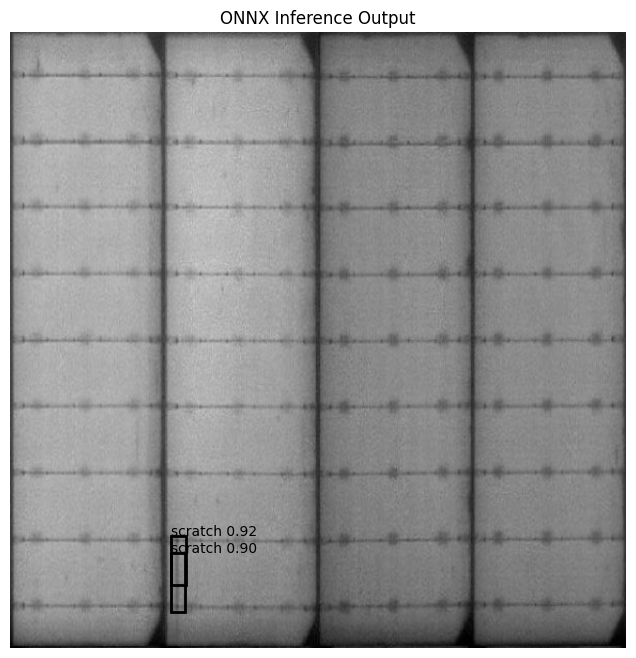

In [34]:
import onnx
import onnxruntime as ort
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1️⃣ Load ONNX model
# ---------------------------------------------------------
onnx_model_path = "/kaggle/working/onnx_models/best_model.onnx"

onnx_model = onnx.load(onnx_model_path)
onnx.checker.check_model(onnx_model)
print("✅ ONNX model structure verified")

ort_session = ort.InferenceSession(onnx_model_path)
print("✅ ONNX Runtime session created")

# ---------------------------------------------------------
# 2️⃣ Get one test sample
# ---------------------------------------------------------
model.eval()

images, targets = next(iter(test_loader))
image = images[0]
image_np = image.permute(1, 2, 0).numpy()

# Resize if needed (must match export size)
image_resized = cv2.resize(image_np, (640, 640))
input_tensor = torch.tensor(image_resized).permute(2, 0, 1).unsqueeze(0).float()
input_tensor = input_tensor.numpy()

# ---------------------------------------------------------
# 3️⃣ Run ONNX inference
# ---------------------------------------------------------
outputs = ort_session.run(None, {"images": input_tensor})

boxes = outputs[0]
labels = outputs[1]
scores = outputs[2]

# Filter by confidence
conf_thresh = 0.4
keep = scores > conf_thresh

boxes = boxes[keep]
labels = labels[keep]
scores = scores[keep]

print(f"Detected {len(boxes)} objects")

# ---------------------------------------------------------
# 4️⃣ Plot result
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.imshow(image_resized)

for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = box
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
    )

    class_name = ID_TO_CLASS_NAME.get(int(label), str(label))
    plt.text(x1, y1,
             f"{class_name} {score:.2f}",
             fontsize=10)

plt.axis("off")
plt.title("ONNX Inference Output")
plt.show()

# zip

In [35]:
import os
import shutil

root_path = '/kaggle/working/'
os.chdir(root_path)

files_in_root = []

for item in os.listdir('.'):
    if item.startswith('.'):
        continue

    # -------------------------------
    # HANDLE DIRECTORIES
    # -------------------------------
    if os.path.isdir(item):

        contents = os.listdir(item)

        # 1️⃣ If folder is empty → delete
        if not contents:
            os.rmdir(item)
            print(f"Removed empty folder: {item}")
            continue

        # Separate files and subfolders
        subfolders = [c for c in contents if os.path.isdir(os.path.join(item, c))]
        files = [c for c in contents if os.path.isfile(os.path.join(item, c))]

        # 2️⃣ If folder has ONLY subfolders (no files)
        if subfolders and not files:
            print(f"{item} contains only subfolders → zipping each separately")

            for sub in subfolders:
                sub_path = os.path.join(item, sub)

                shutil.make_archive(sub, 'zip', sub_path)
                shutil.rmtree(sub_path)
                print(f"Zipped and deleted subfolder: {sub}")

            # Remove parent folder after subfolders handled
            os.rmdir(item)
            print(f"Removed parent folder: {item}")

        # 3️⃣ If folder has ANY files (even with subfolders)
        else:
            shutil.make_archive(item, 'zip', item)
            shutil.rmtree(item)
            print(f"Zipped and deleted full folder: {item}")

    # -------------------------------
    # HANDLE ROOT FILES
    # -------------------------------
    elif os.path.isfile(item):
        if not item.endswith('.zip') and not item.endswith('.pth'):
            files_in_root.append(item)

# -------------------------------
# ZIP ROOT FILES
# -------------------------------
if files_in_root:
    temp_dir = 'root_files_temp'
    os.makedirs(temp_dir, exist_ok=True)

    for f in files_in_root:
        shutil.move(f, os.path.join(temp_dir, f))

    shutil.make_archive('root', 'zip', temp_dir)
    shutil.rmtree(temp_dir)
    print("Zipped and deleted root level files into root.zip (excluding .pth files)")

Removed empty folder: test
test_results contains only subfolders → zipping each separately
Zipped and deleted subfolder: final_model
Zipped and deleted subfolder: best_model
Removed parent folder: test_results
Zipped and deleted full folder: metrics
Zipped and deleted full folder: onnx_models
Zipped and deleted full folder: models
Zipped and deleted full folder: logs
final_dataset contains only subfolders → zipping each separately
Zipped and deleted subfolder: test
Zipped and deleted subfolder: train
Zipped and deleted subfolder: train_aug
Zipped and deleted subfolder: val
Removed parent folder: final_dataset
Zipped and deleted root level files into root.zip (excluding .pth files)
